In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('../data/predictive_maintenance.csv')

# Display shape and column summary
print(f"Dataset Shape: {df.shape}")
print("\n--- Columns & Data Types ---")
print(df.info())

# Preview first 5 rows
df.head()

Dataset Shape: (10000, 14)

--- Columns & Data Types ---
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [2]:
# Rename columns to cleaner Pythonic names
df.columns = df.columns.str.strip().str.replace('[', '', regex=False).str.replace(']', '', regex=False)
df.rename(columns={
    'Air temperature K': 'air_temp',
    'Process temperature K': 'process_temp',
    'Rotational speed rpm': 'rotational_speed',
    'Torque Nm': 'torque',
    'Tool wear min': 'tool_wear',
    'Machine failure': 'failure'
}, inplace=True)

# 1. Failure rate overview
failure_counts = df['failure'].value_counts()
failure_pct = df['failure'].value_counts(normalize=True) * 100

print(f"Normal Operations (0): {failure_counts[0]} ({failure_pct[0]:.2f}%)")
print(f"Machine Failures (1):  {failure_counts[1]} ({failure_pct[1]:.2f}%)")

# 2. Key mechanical sensor statistics
df[['air_temp', 'process_temp', 'rotational_speed', 'torque', 'tool_wear']].describe()

Normal Operations (0): 9661 (96.61%)
Machine Failures (1):  339 (3.39%)


,air_temp,process_temp,rotational_speed,torque,tool_wear
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000
std,2.000259,1.483734,179.284096,9.968934,63.654147
min,295.300000,305.700000,1168.000000,3.800000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000


In [3]:
import numpy as np

# 1. Temperature Difference (Delta T in Kelvin)
# Measures heat dissipation capability during machine operation
df['temp_diff'] = df['process_temp'] - df['air_temp']

# 2. Mechanical Power Output (in Watts)
# Power (W) = Torque (Nm) * Angular Velocity (rad/s)
# rad/s = rotational_speed * (2 * pi / 60)
df['power_watts'] = df['torque'] * (df['rotational_speed'] * (2 * np.pi / 60))

# 3. Overstrain Load Factor
# Measures combined mechanical stress on worn tooling
df['overstrain_factor'] = df['torque'] * df['tool_wear']

# Inspect engineered feature distributions
df[['temp_diff', 'power_watts', 'overstrain_factor']].describe()

,temp_diff,power_watts,overstrain_factor
count,10000.000000,10000.000000,10000.000000
mean,10.000630,6279.744953,4314.664550
std,1.001094,1067.418295,2826.567692
min,7.600000,1148.440610,0.000000
25%,9.300000,5561.184484,1963.650000
50%,9.800000,6271.027344,4012.950000
75%,11.000000,7003.002724,6279.000000
max,12.100000,10469.923005,16497.000000


In [6]:
pip install matplotlib seaborn

  Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl (9.5 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl (75 kB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

   ---------------------------------------- 0/7 [pyparsing]
   ----------- -----

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


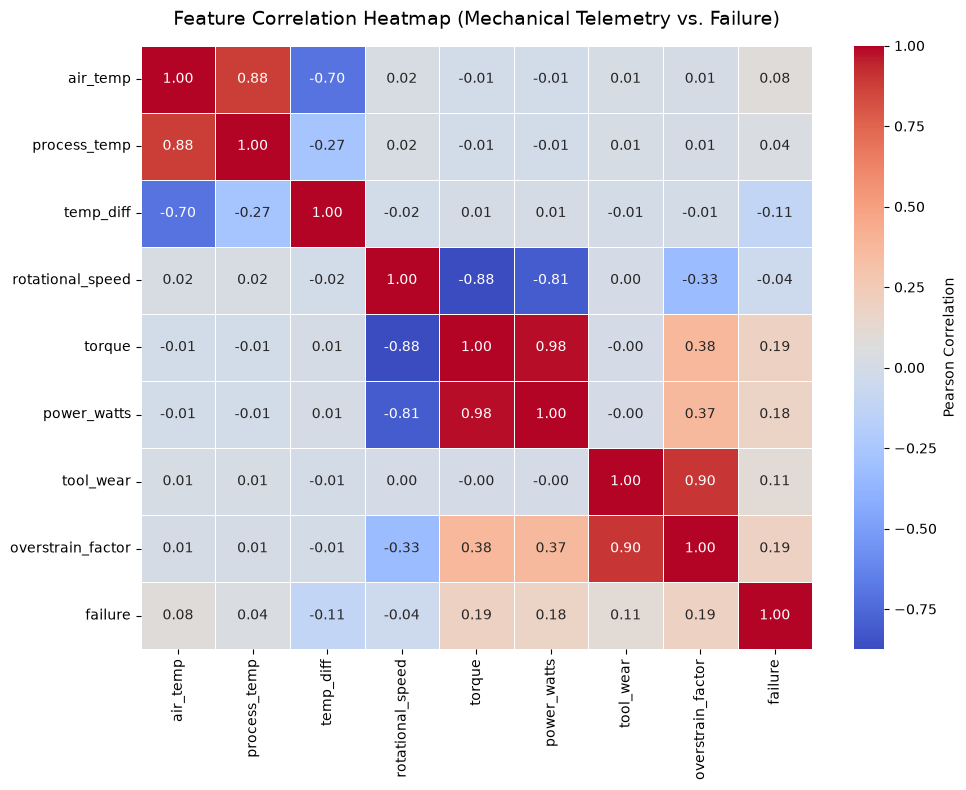


--- Feature Correlation with Machine Failure ---
failure              1.000000
torque               0.191321
overstrain_factor    0.190427
power_watts          0.176039
tool_wear            0.105448
air_temp             0.082556
process_temp         0.035946
rotational_speed    -0.044188
temp_diff           -0.111676
Name: failure, dtype: float64


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select key numerical features and target
heatmap_cols = [
    'air_temp', 'process_temp', 'temp_diff', 
    'rotational_speed', 'torque', 'power_watts', 
    'tool_wear', 'overstrain_factor', 'failure'
]

# Compute correlation matrix
corr_matrix = df[heatmap_cols].corr()

# Set up heatmap figure
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm', 
    linewidths=0.5,
    cbar_kws={'label': 'Pearson Correlation'}
)

plt.title('Feature Correlation Heatmap (Mechanical Telemetry vs. Failure)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Isolate direct correlations with failure
print("\n--- Feature Correlation with Machine Failure ---")
print(corr_matrix['failure'].sort_values(ascending=False))

C:\Users\welcomm\AppData\Local\Temp\ipykernel_13612\4070306354.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=mode_counts, x='Label', y='Count', palette='Blues_r')


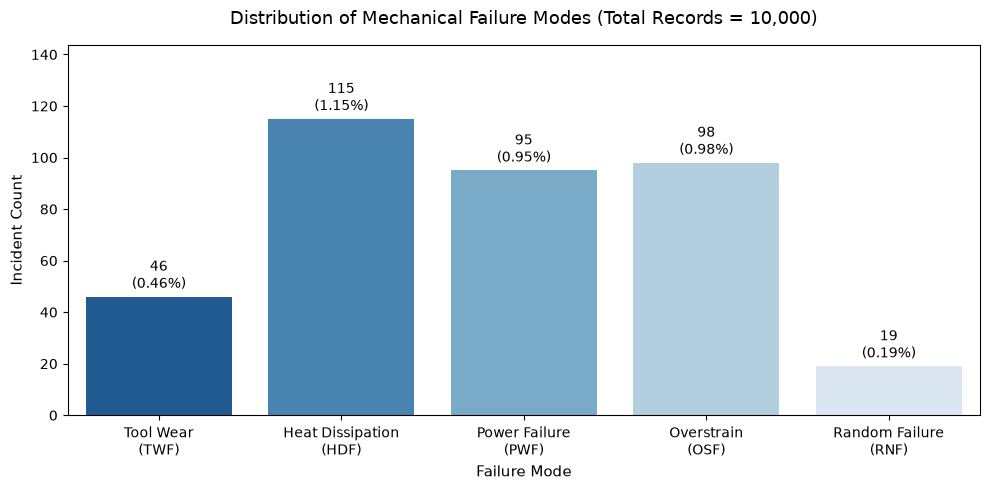

--- Breakdown of Failure Causes ---
TWF: 46 cases (0.46%)
HDF: 115 cases (1.15%)
PWF: 95 cases (0.95%)
OSF: 98 cases (0.98%)
RNF: 19 cases (0.19%)


In [8]:
# Identify failure mode columns
failure_modes = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

# Calculate occurrence count and percentage
mode_counts = df[failure_modes].sum().reset_index()
mode_counts.columns = ['Failure_Mode', 'Count']

mode_labels = {
    'TWF': 'Tool Wear\n(TWF)',
    'HDF': 'Heat Dissipation\n(HDF)',
    'PWF': 'Power Failure\n(PWF)',
    'OSF': 'Overstrain\n(OSF)',
    'RNF': 'Random Failure\n(RNF)'
}
mode_counts['Label'] = mode_counts['Failure_Mode'].map(mode_labels)

# Plot distribution bar chart
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=mode_counts, x='Label', y='Count', palette='Blues_r')

# Annotate counts and percentages on top of each bar
for p in ax.patches:
    height = p.get_height()
    pct = (height / len(df)) * 100
    ax.annotate(f'{int(height)}\n({pct:.2f}%)',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10, xytext=(0, 3),
                textcoords='offset points')

plt.title('Distribution of Mechanical Failure Modes (Total Records = 10,000)', fontsize=13, pad=15)
plt.xlabel('Failure Mode', fontsize=11)
plt.ylabel('Incident Count', fontsize=11)
plt.ylim(0, mode_counts['Count'].max() * 1.25)
plt.tight_layout()
plt.show()

# Display summary table
print("--- Breakdown of Failure Causes ---")
for idx, row in mode_counts.iterrows():
    print(f"{row['Failure_Mode']}: {int(row['Count'])} cases ({(row['Count']/len(df))*100:.2f}%)")

In [9]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix
import joblib

# 1. Feature Selection & Train-Test Split
feature_cols = [
    'air_temp', 'process_temp', 'temp_diff', 
    'rotational_speed', 'torque', 'power_watts', 
    'tool_wear', 'overstrain_factor'
]
X = df[feature_cols]
y = df['failure']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Handle Class Imbalance (3.39% failures)
ratio = (len(y_train) - sum(y_train)) / sum(y_train)

model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=ratio,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

# 3. Financial Cost Matrix Optimization
# Cost Matrix:
# - False Negative (Unscheduled Breakdown): $10,000
# - False Positive (Unnecessary Maintenance): $1,200
# - True Positive (Scheduled Maintenance): $1,200
# - True Negative (Normal Operation): $0

y_probs = model.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.01, 0.99, 100)
costs = []

for t in thresholds:
    y_pred_t = (y_probs >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    
    total_cost = (fn * 10000) + (fp * 1200) + (tp * 1200)
    costs.append(total_cost)

best_idx = np.argmin(costs)
best_threshold = thresholds[best_idx]
min_cost = costs[best_idx]

# Compare against standard default threshold (0.5)
y_pred_default = (y_probs >= 0.5).astype(int)
tn_d, fp_d, fn_d, tp_d = confusion_matrix(y_test, y_pred_default).ravel()
default_cost = (fn_d * 10000) + (fp_d * 1200) + (tp_d * 1200)

print("--- FINANCIAL COST MATRIX EVALUATION ---")
print(f"Default (0.50) Threshold Cost: ${default_cost:,.2f}")
print(f"Optimal ({best_threshold:.2f}) Threshold Cost: ${min_cost:,.2f}")
print(f"Total Financial Risk Savings: ${default_cost - min_cost:,.2f}")

# 4. Save Model Artifacts
joblib.dump(model, '../artifacts/model.pkl')
joblib.dump(best_threshold, '../artifacts/threshold.pkl')
print("\n[SUCCESS] Saved model.pkl and threshold.pkl in artifacts/")

--- FINANCIAL COST MATRIX EVALUATION ---
Default (0.50) Threshold Cost: $224,400.00
Optimal (0.65) Threshold Cost: $189,600.00
Total Financial Risk Savings: $34,800.00

[SUCCESS] Saved model.pkl and threshold.pkl in artifacts/


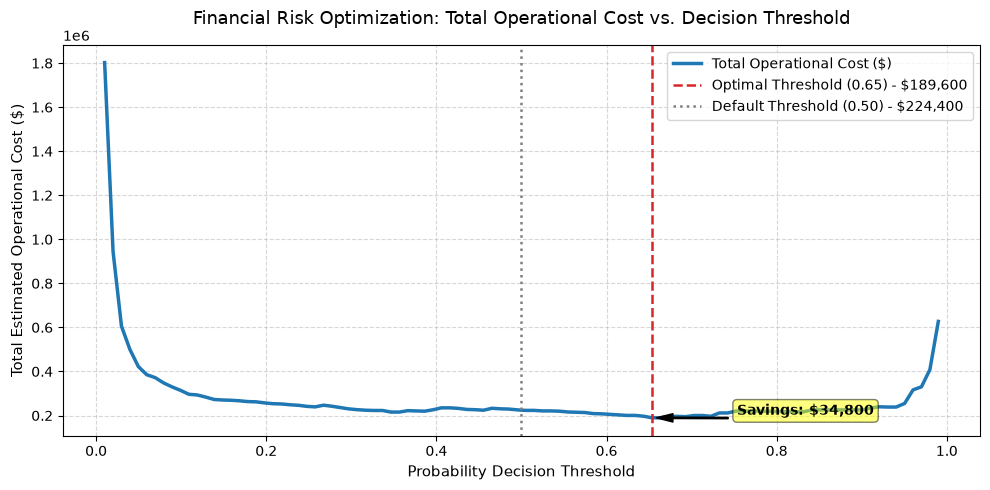

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(thresholds, costs, color='#1f77b4', linewidth=2.5, label='Total Operational Cost ($)')

# Highlight optimal threshold
plt.axvline(x=best_threshold, color='#d62728', linestyle='--', linewidth=1.8, 
            label=f'Optimal Threshold ({best_threshold:.2f}) - ${min_cost:,.0f}')

# Highlight default threshold (0.50)
plt.axvline(x=0.50, color='#7f7f7f', linestyle=':', linewidth=1.8, 
            label=f'Default Threshold (0.50) - ${default_cost:,.0f}')

# Annotate financial savings delta
plt.annotate(
    f'Savings: ${default_cost - min_cost:,.0f}',
    xy=(best_threshold, min_cost),
    xytext=(best_threshold + 0.1, min_cost + (default_cost - min_cost) * 0.4),
    arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
    fontsize=10,
    fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5)
)

plt.title('Financial Risk Optimization: Total Operational Cost vs. Decision Threshold', fontsize=13, pad=15)
plt.xlabel('Probability Decision Threshold', fontsize=11)
plt.ylabel('Total Estimated Operational Cost ($)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()

In [11]:
import os
import joblib

artifacts = {
    'Model File': '../artifacts/model.pkl',
    'Threshold File': '../artifacts/threshold.pkl'
}

print("--- ARTIFACT VERIFICATION ---")
all_valid = True

for name, path in artifacts.items():
    if os.path.exists(path):
        size_kb = os.path.getsize(path) / 1024
        print(f"✅ {name} exists! Location: '{path}' ({size_kb:.2f} KB)")
    else:
        print(f"❌ {name} is MISSING from '{path}'")
        all_valid = False

# Attempt loading the artifacts into memory
if all_valid:
    try:
        model = joblib.load(artifacts['Model File'])
        threshold = joblib.load(artifacts['Threshold File'])
        print(f"\n[SUCCESS] Loaded model ({type(model).__name__}) and threshold ({threshold:.2f}) smoothly!")
    except Exception as e:
        print(f"\n[ERROR] Files exist but failed to load: {e}")

--- ARTIFACT VERIFICATION ---
✅ Model File exists! Location: '../artifacts/model.pkl' (223.80 KB)
✅ Threshold File exists! Location: '../artifacts/threshold.pkl' (0.11 KB)

[SUCCESS] Loaded model (XGBClassifier) and threshold (0.65) smoothly!
